In [5]:
import jax

jax.config.update("jax_enable_x64", True)

import time

import imageio_ffmpeg
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import HTML
from jax.experimental import checkify
from jax_tqdm import scan_tqdm
from scipy.io import loadmat
from statsmodels.tsa.stattools import acf
from tqdm.auto import tqdm, trange

from nanopinv.distribution import MultivariateNormalCholesky
from nanopinv.physics_jax import build_travel_time_points
from nanopinv.sampler_jax import (
    ExtendedMetropolisChain,
    IterationState,
    ParallelTemperingSampler,
    ProposalDistribution,
    initalize_betas,
)
from nanopinv.types import Observations
from nanopinv.utils import StatefulRNGKey, make_pytree_spec
from nanopinv.variance import get_distance_matrix, spherical

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Correctness

In [6]:
# 1) Setup grid
N = 101
x = np.linspace(-1.0, 1.0, N)
y = np.linspace(-1.0, 1.0, N)

# 2) Setup source and receivers
sources = np.array([[0.0, 0.0]])  # (N_sources=1, ndim=2)

X, Y = np.meshgrid(x, y, indexing="ij")
receivers_flat = np.stack([X.ravel(), Y.ravel()], axis=-1)  # (N_receivers, 2)

# Keep receivers batched by source to match model vmap usage
receivers = np.expand_dims(receivers_flat, axis=0)  # (1, N_receivers, 2)

# 3) Setup speed model
speed = np.ones((N, N), dtype=np.float64)

# 4) Analytical solution
tau_exact = np.sqrt(receivers_flat[:, 0] ** 2 + receivers_flat[:, 1] ** 2)

# Keep solver6 if you want to explicitly see failure handling
# solvers = ["skfmm", "fsm", "solver3", "solver4", "solver5", "solver6"]
solvers = ["skfmm", "solver3", "solver4", "solver5", "solver6"]

n_subsequent_runs = 2

print(f"Testing Eikonal solvers on {N}x{N} grid")
print("-" * 120)
print(
    f"{'Solver':<10} | "
    f"{'L_inf Error':<13} | "
    f"{'L1 Error':<13} | "
    f"{'Compile+Run [s]':<16} | "
    f"{'Avg next 2 [s]':<14} | "
    f"{'Std next 2 [s]':<14}"
)
print("-" * 120)

for solver_name in solvers:
    model_fn = build_travel_time_points(
        sources,
        receivers,
        *[x, y],
        order=1,
        window=1,
        solver=solver_name,
        fsm_max_sweeps=30,
        fsm_tolerance=1e-1,
        jacobi_max_iter=300,
    )

    # First call: includes JIT compile + run
    t0 = time.perf_counter()
    tau0 = model_fn(speed)
    tau0 = jax.block_until_ready(tau0)
    t_compile_run = time.perf_counter() - t0

    # Subsequent calls: already compiled
    subsequent_times = []
    for _ in range(n_subsequent_runs):
        t1 = time.perf_counter()
        tau_i = model_fn(speed)
        tau_i = jax.block_until_ready(tau_i)
        subsequent_times.append(time.perf_counter() - t1)

    t_sub_avg = float(np.mean(subsequent_times))
    t_sub_std = float(np.std(subsequent_times))

    # Error metrics from first result (same numerically as subsequent runs)
    tau_pred = np.asarray(tau0[0])  # output shape expected: (1, N_receivers)
    abs_err = np.abs(tau_pred - tau_exact)
    l_inf = float(np.max(abs_err))
    l_1 = float(np.mean(abs_err))

    print(
        f"{solver_name:<10} | "
        f"{l_inf:<13.6e} | "
        f"{l_1:<13.6e} | "
        f"{t_compile_run:<16.6f} | "
        f"{t_sub_avg:<14.6f} | "
        f"{t_sub_std:<14.6f}"
    )


Testing Eikonal solvers on 101x101 grid
------------------------------------------------------------------------------------------------------------------------
Solver     | L_inf Error   | L1 Error      | Compile+Run [s]  | Avg next 2 [s] | Std next 2 [s]
------------------------------------------------------------------------------------------------------------------------
skfmm      | 2.629691e-02  | 1.492207e-02  | 0.169724         | 0.013120       | 0.000070      
solver3    | 2.629691e-02  | 1.492207e-02  | 0.433383         | 0.003389       | 0.000050      
solver4    | 2.629691e-02  | 1.492207e-02  | 0.645951         | 0.011649       | 0.000075      
solver5    | 2.629691e-02  | 1.492207e-02  | 0.961297         | 0.246648       | 0.000023      
solver6    | nan           | nan           | 6.803022         | 6.236427       | 0.000331      


# Benchmark

Number of data points: 702
Number of dimensions: 2


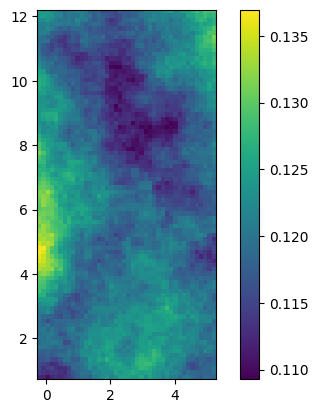

In [7]:
# Load dataset
M = loadmat("AM13_data.mat")

N_data, N_dim = M["S"].shape
sources = jnp.asarray(M["S"])  # Shape: (N_data, N_dim)
receivers = jnp.asarray(M["R"])  # Shape: (N_data, N_dim)
assert sources.shape == receivers.shape, (
    "Sources and receivers must have the same shape."
)

data_obs = M["d_obs"].flatten()
data_std = M["d_std"].flatten()
data_std = 0.4 * np.ones_like(
    data_obs
)  # For whatever reason, we overwrite this, maybe original data was wrong?

print(f"Number of data points: {N_data}")
print(f"Number of dimensions: {N_dim}")

# Set up grid
dx = 0.135
x = jnp.arange(-2 * dx, 5 + 2 * dx, dx)
y = jnp.arange(1 - 2 * dx, 12 + 2 * dx, dx)
r = (
    x,
    y,
)
grid_shape = (
    len(x),
    len(y),
)

# Set up prior
m0 = 0.12
range_ = 7.0
partial_sill = 0.00003
nugget = 1e-10

h = get_distance_matrix(*r)
cov = spherical(h, range_=range_, partial_sill=partial_sill, nugget=nugget)
prior = MultivariateNormalCholesky(shape=grid_shape, cov=cov, mean=m0)

# Set up forward model
forward_model = build_travel_time_points(sources, receivers, x, y, solver="solver3")

# Set up proposal distribution
proposal_dist = ProposalDistribution(dist=prior, step_size=0.1)

# Set up observations
obs = Observations(
    data_obs=data_obs,
    data_std=data_std,
)
\
# Set up RNG
skey = StatefulRNGKey(0)

realisation = prior(skey())

plt.imshow(
    realisation.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar()

In [8]:
# ============================================================
# Benchmark cell with live progress + cancellable heavy runs
# ============================================================
# Cancel options:
# 1) Press interrupt in Jupyter (stop button / keyboard interrupt) any time.
# 2) Interactive prompts can skip heavy runs per solver or for all remaining solvers.
# 3) Auto-skip heavy runs for slow solvers via thresholds below.

# ----------------------------
# Config
# ----------------------------
N_CHAINS_HEAVY = 32
N_REPEAT_SINGLE = 3
N_REPEAT_HEAVY = 2
FSM_TOL = 1e-3
MIN_SPEED = 1e-6

RUN_HEAVY = True
HEAVY_POLICY = "ask_slow"      # "always", "ask", "ask_slow", "never"
SLOW_SINGLE_THRESHOLD_S = 0.75 # used when HEAVY_POLICY == "ask_slow"
AUTO_SKIP_HEAVY_IF_SINGLE_GT = None  # e.g. 3.0 to auto-skip heavy if single mean > 3s
CONFIRM_EVERY_HEAVY = False    # if True, asks before every heavy run
SKIP_HEAVY_SOLVERS = set(["fsm", "solver4", "solver5"])     # e.g. {"skfmm"} to never run heavy for specific solvers

SOLVERS = [
    ("skfmm", {}),
    # ("fsm", {"fsm_tolerance": FSM_TOL}),
    ("solver3", {"fsm_tolerance": FSM_TOL}),
    ("solver4", {"fsm_tolerance": FSM_TOL}),
    ("solver5", {"fsm_tolerance": FSM_TOL}),
]

# ----------------------------
# Helpers
# ----------------------------
def ask_choice(prompt, default="n", valid=("y", "n")):
    try:
        s = input(prompt).strip().lower()
    except (EOFError, KeyboardInterrupt):
        s = ""
    if not s:
        s = default
    if s not in valid:
        s = default
    return s

def run_and_block(fn, arg):
    out = fn(arg)
    out = jax.block_until_ready(out)
    return out

def timed_benchmark(fn, arg, n_repeat, label):
    # Compile + first execution
    t0 = time.perf_counter()
    out0 = run_and_block(fn, arg)
    compile_plus_first_s = time.perf_counter() - t0
    print(f"  {label:<6} compile+first: {compile_plus_first_s:.4f}s", flush=True)

    # Steady-state repeats with live progress
    times = []
    out = out0
    for i in range(1, n_repeat + 1):
        t1 = time.perf_counter()
        out = run_and_block(fn, arg)
        dt = time.perf_counter() - t1
        times.append(dt)
        print(
            f"  {label:<6} repeat {i:>2}/{n_repeat}: {dt:.4f}s "
            f"(mean so far: {np.mean(times):.4f}s)",
            flush=True,
        )

    return {
        "compile_plus_first_s": compile_plus_first_s,
        "steady_mean_s": float(np.mean(times)),
        "steady_min_s": float(np.min(times)),
        "steady_std_s": float(np.std(times)),
        "output_shape": tuple(np.asarray(out).shape),
    }

def fmt_num(v, width=12, digits=4):
    if v is None:
        return f"{'--':>{width}}"
    if isinstance(v, float) and np.isnan(v):
        return f"{'--':>{width}}"
    return f"{v:>{width}.{digits}f}"

# ----------------------------
# Inputs (expects earlier notebook vars)
# ----------------------------
if "realisation" in globals():
    m_single = jnp.asarray(realisation)
else:
    m_single = prior(skey())

m_single = jnp.maximum(m_single, MIN_SPEED)
m_heavy = jnp.maximum(prior(skey(), num_samples=N_CHAINS_HEAVY), MIN_SPEED)
n_obs = int(np.asarray(data_obs).shape[0])

# ----------------------------
# Main benchmark loop
# ----------------------------
rows = []
heavy_mode_override = None  # None, "always", "never"
abort_all = False

print("Starting solver benchmark...", flush=True)
print(f"Heavy batch size: {N_CHAINS_HEAVY}", flush=True)
print("-" * 80, flush=True)

for idx, (solver_name, solver_kwargs) in enumerate(SOLVERS, start=1):
    print(f"\n[{idx}/{len(SOLVERS)}] Solver: {solver_name}", flush=True)

    row = {
        "solver": solver_name,
        "error": None,
        "single": None,
        "heavy": None,
        "heavy_status": None,
    }

    # Build model
    try:
        fwd = build_travel_time_points(
            sources, receivers, x, y, solver=solver_name, **solver_kwargs
        )
        print("  model build: ok", flush=True)
    except Exception as e:
        row["error"] = f"build failed: {repr(e)}"
        print(f"  model build: FAILED -> {row['error']}", flush=True)
        rows.append(row)
        continue

    # Single benchmark
    try:
        single = timed_benchmark(fwd, m_single, N_REPEAT_SINGLE, label="single")
        row["single"] = single
        print(
            f"  single summary: mean={single['steady_mean_s']:.4f}s, "
            f"min={single['steady_min_s']:.4f}s, out={single['output_shape']}",
            flush=True,
        )
    except KeyboardInterrupt:
        print("\nInterrupted during single benchmark. Stopping benchmark.", flush=True)
        abort_all = True
        row["heavy_status"] = "not attempted"
        rows.append(row)
        break
    except Exception as e:
        row["error"] = f"single run failed: {repr(e)}"
        print(f"  single run: FAILED -> {row['error']}", flush=True)
        rows.append(row)
        continue

    # Decide heavy run
    run_heavy = RUN_HEAVY
    skip_reason = None

    if not RUN_HEAVY:
        run_heavy = False
        skip_reason = "RUN_HEAVY is False"

    if run_heavy and solver_name in SKIP_HEAVY_SOLVERS:
        run_heavy = False
        skip_reason = "solver in SKIP_HEAVY_SOLVERS"

    if run_heavy and HEAVY_POLICY == "never":
        run_heavy = False
        skip_reason = "HEAVY_POLICY=never"

    if run_heavy and AUTO_SKIP_HEAVY_IF_SINGLE_GT is not None:
        if single["steady_mean_s"] > float(AUTO_SKIP_HEAVY_IF_SINGLE_GT):
            run_heavy = False
            skip_reason = (
                f"auto-skip: single mean {single['steady_mean_s']:.3f}s "
                f"> {AUTO_SKIP_HEAVY_IF_SINGLE_GT:.3f}s"
            )

    if run_heavy and heavy_mode_override == "never":
        run_heavy = False
        skip_reason = "user selected skip all remaining heavy runs"

    need_prompt = False
    if run_heavy and heavy_mode_override is None:
        if HEAVY_POLICY == "ask":
            need_prompt = True
        elif HEAVY_POLICY == "ask_slow" and single["steady_mean_s"] >= SLOW_SINGLE_THRESHOLD_S:
            need_prompt = True
        elif CONFIRM_EVERY_HEAVY:
            need_prompt = True

    if run_heavy and need_prompt:
        choice = ask_choice(
            f"  Run heavy ({N_CHAINS_HEAVY} batch) for {solver_name}? "
            "[y]es / [n]o / [a]ll remaining / [s]kip all remaining / [q]uit: ",
            default="n",
            valid=("y", "n", "a", "s", "q"),
        )
        if choice == "a":
            heavy_mode_override = "always"
            run_heavy = True
        elif choice == "s":
            heavy_mode_override = "never"
            run_heavy = False
            skip_reason = "user selected skip all remaining heavy runs"
        elif choice == "q":
            run_heavy = False
            skip_reason = "user quit benchmark"
            abort_all = True
        elif choice == "y":
            run_heavy = True
        else:
            run_heavy = False
            skip_reason = "user skipped heavy run"

    # Heavy benchmark
    if run_heavy:
        try:
            heavy = timed_benchmark(fwd, m_heavy, N_REPEAT_HEAVY, label="heavy")
            row["heavy"] = heavy
            row["heavy_status"] = "completed"
            print(
                f"  heavy summary: mean={heavy['steady_mean_s']:.4f}s, "
                f"min={heavy['steady_min_s']:.4f}s, out={heavy['output_shape']}",
                flush=True,
            )
        except KeyboardInterrupt:
            choice = ask_choice(
                "\nHeavy run interrupted. Continue with next solver? [y]es / [q]uit: ",
                default="y",
                valid=("y", "q"),
            )
            row["heavy_status"] = "interrupted"
            row["heavy"] = None
            if choice == "q":
                abort_all = True
            print("  heavy run interrupted; continuing summary.", flush=True)
        except Exception as e:
            row["heavy_status"] = f"failed: {repr(e)}"
            row["heavy"] = None
            print(f"  heavy run: FAILED -> {repr(e)}", flush=True)
    else:
        row["heavy_status"] = f"skipped: {skip_reason}"
        print(f"  heavy run skipped: {skip_reason}", flush=True)

    rows.append(row)
    if abort_all:
        break

# ----------------------------
# Final summary table
# ----------------------------
print("\n" + "=" * 120)
print("FINAL SUMMARY")
print("=" * 120)

header = (
    f"{'solver':<10}"
    f"{'single_mean[s]':>15}"
    f"{'heavy32_mean[s]':>17}"
    f"{'single_compile[s]':>18}"
    f"{'heavy32_compile[s]':>19}"
    f"{'tp_single[obs/s]':>18}"
    f"{'tp_heavy[obs/s]':>18}"
    f"{'tp_scaling[x]':>14}"
    f"{'heavy_status':>20}"
)
print(header)
print("-" * len(header))

for r in rows:
    solver = r["solver"]
    err = r["error"]
    single = r["single"]
    heavy = r["heavy"]
    heavy_status = r["heavy_status"] if r["heavy_status"] is not None else "--"

    if err is not None:
        print(
            f"{solver:<10}"
            f"{'--':>15}{'--':>17}{'--':>18}{'--':>19}{'--':>18}{'--':>18}{'--':>14}"
            f"{'ERROR':>20}"
        )
        print(f"  -> {err}")
        continue

    single_mean = single["steady_mean_s"]
    single_compile = single["compile_plus_first_s"]
    tp_single = n_obs / single_mean

    if heavy is not None:
        heavy_mean = heavy["steady_mean_s"]
        heavy_compile = heavy["compile_plus_first_s"]
        tp_heavy = (N_CHAINS_HEAVY * n_obs) / heavy_mean
        tp_scale = tp_heavy / tp_single
    else:
        heavy_mean = np.nan
        heavy_compile = np.nan
        tp_heavy = np.nan
        tp_scale = np.nan

    print(
        f"{solver:<10}"
        f"{fmt_num(single_mean, 15, 4)}"
        f"{fmt_num(heavy_mean, 17, 4)}"
        f"{fmt_num(single_compile, 18, 4)}"
        f"{fmt_num(heavy_compile, 19, 4)}"
        f"{fmt_num(tp_single, 18, 1)}"
        f"{fmt_num(tp_heavy, 18, 1)}"
        f"{fmt_num(tp_scale, 14, 2)}"
        f"{heavy_status[:20]:>20}"
    )

print("\nDone.", flush=True)

Starting solver benchmark...
Heavy batch size: 32
--------------------------------------------------------------------------------

[1/4] Solver: skfmm
  model build: ok


  single compile+first: 0.2006s
  single repeat  1/3: 0.0412s (mean so far: 0.0412s)


/home/jkl/Code/nanopinv/.venv/lib/python3.14/site-packages/jax/_src/interpreters/mlir.py:1326: UserWarning: Some donated buffers were not usable: float64[42,86].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


  single repeat  2/3: 0.0318s (mean so far: 0.0365s)
  single repeat  3/3: 0.0369s (mean so far: 0.0366s)
  single summary: mean=0.0366s, min=0.0318s, out=(702,)


/home/jkl/Code/nanopinv/.venv/lib/python3.14/site-packages/jax/_src/interpreters/mlir.py:1326: UserWarning: Some donated buffers were not usable: float64[32,42,86].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


  heavy  compile+first: 1.0042s
  heavy  repeat  1/2: 0.8254s (mean so far: 0.8254s)
  heavy  repeat  2/2: 0.8604s (mean so far: 0.8429s)
  heavy summary: mean=0.8429s, min=0.8254s, out=(32, 702)

[2/4] Solver: solver3
  model build: ok
  single compile+first: 0.6130s
  single repeat  1/3: 0.0102s (mean so far: 0.0102s)
  single repeat  2/3: 0.0102s (mean so far: 0.0102s)
  single repeat  3/3: 0.0101s (mean so far: 0.0102s)
  single summary: mean=0.0102s, min=0.0101s, out=(702,)
  heavy  compile+first: 1.2752s
  heavy  repeat  1/2: 0.3703s (mean so far: 0.3703s)
  heavy  repeat  2/2: 0.3703s (mean so far: 0.3703s)
  heavy summary: mean=0.3703s, min=0.3703s, out=(32, 702)

[3/4] Solver: solver4
  model build: ok
  single compile+first: 1.1118s
  single repeat  1/3: 0.2502s (mean so far: 0.2502s)
  single repeat  2/3: 0.2500s (mean so far: 0.2501s)
  single repeat  3/3: 0.2498s (mean so far: 0.2500s)
  single summary: mean=0.2500s, min=0.2498s, out=(702,)
  heavy run skipped: solver in S